# Iteratively regularised Gauss-Newton

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/torchsolve/blob/main/examples/04-irgnm.ipynb)

A nonlinear least-squares fit that starts heavily regularised and lets the
regularisation decay as the estimate improves — Bakushinsky's iteratively
regularised Gauss-Newton, and the reason the linear solvers in this package
exist. Each step solves a linearised problem pulled towards a reference, and
the pull is what keeps an ill-posed step from running away before there is
anything to run towards.

The schedule is BART's: `alpha <- (alpha - alpha_min) / reduction +
alpha_min`, halving by default.

In [1]:
try:
    import torchsolve  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torchsolve", "matplotlib"],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from torchsolve import CGSolver, LstsqSolver, gauss_newton

# Two-compartment decay: four parameters, and the two rates are close enough
# that the fit is genuinely ill-posed from a bad start.
TIME = torch.linspace(0, 2.0, 64, dtype=torch.float64)
TRUTH = torch.tensor([1.0, 4.0, 0.6, 1.1], dtype=torch.float64)


def biexponential(p):
    """Indexed with an ellipsis, so one voxel and a batch of them both work."""
    return p[..., 0:1] * torch.exp(-p[..., 1:2] * TIME) + p[..., 2:3] * torch.exp(
        -p[..., 3:4] * TIME
    )


generator = torch.Generator().manual_seed(0)
data = biexponential(TRUTH) + 0.02 * torch.randn(
    TIME.shape, generator=generator, dtype=torch.float64
)
start = torch.tensor([0.6, 2.5, 0.8, 2.0], dtype=torch.float64)
print("start ", start.tolist())
print("truth ", TRUTH.tolist())

start  [0.6, 2.5, 0.8, 2.0]
truth  [1.0, 4.0, 0.6, 1.1]


## What the schedule does

Held at a fixed weight the fit either stalls, because it is still being pulled
towards a start it has outgrown, or walks out of the basin, because the early
steps were never restrained. Decaying it does both jobs in turn: heavy pull
while the linearisation is worthless, none once it is not.

In [3]:
error = lambda p: float((p - TRUTH).norm() / TRUTH.norm())

found = gauss_newton(
    data=data, operator=biexponential, x0=start, iterations=12, alpha=1.0
)
print(f"alpha decaying   {error(found.solution):.2e}   {found.alphas[:4]}...")
for fixed in (1.0, 1e-2, 1e-6):
    held = gauss_newton(
        data=data,
        operator=biexponential,
        x0=start,
        iterations=12,
        alpha=fixed,
        alpha_min=fixed,
    )
    print(f"alpha held {fixed:<7g} {error(held.solution):.2e}")

/home/mcencini/torchsolve/.venv/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


alpha decaying   1.24e-01   [1.0, 0.5, 0.25, 0.125]...
alpha held 1       4.13e-01
alpha held 0.01    1.53e-01
alpha held 1e-06   5.89e+00


On noiseless data the smallest fixed weight wins outright -- there is nothing
for the regularisation to protect against, and every step is worth taking in
full. The schedule is what makes the same call work in both cases without
being told which one it is in.

## The inner solver is a seam

Each Newton step is a linear problem, and `solver=` is what solves it. A small
dense one is a `LstsqSolver`; a matrix-free one is a `CGSolver`; anything that
takes a `LinearProblem` and returns a step works, which is where a proximal or
ADMM solver would go for constraints this package does not impose.

In [4]:
for name, solver in (("CG (default)", CGSolver()), ("lstsq", LstsqSolver())):
    result = gauss_newton(
        data=data, operator=biexponential, x0=start, solver=solver, iterations=12
    )
    print(f"{name:<14} {error(result.solution):.2e}")

CG (default)   1.24e-01
lstsq          1.24e-01


## A batch of them

`batch_dims` says how many leading axes of the start are independent
problems, which is the multi-voxel case: one fit per voxel, all at once.

In [5]:
VOXELS = 512
rates = torch.linspace(0.8, 1.6, VOXELS, dtype=torch.float64)
batch_truth = TRUTH.repeat(VOXELS, 1).clone()
batch_truth[:, 3] = rates


# The model above already takes a batch, because it indexes with an ellipsis;
# batch_dims tells the solver that the leading axis is independent problems, so
# the Jacobian is built per voxel and the steps are solved all at once.
batch_data = biexponential(batch_truth)
batch_start = start.repeat(VOXELS, 1)
fitted = gauss_newton(
    data=batch_data,
    operator=biexponential,
    x0=batch_start,
    solver=LstsqSolver(),
    batch_dims=1,
    iterations=12,
)
worst = (fitted.solution - batch_truth).norm(dim=-1) / batch_truth.norm(dim=-1)
print(f"{VOXELS} voxels at once, worst relative error {worst.max():.2e}")

512 voxels at once, worst relative error 4.72e-02


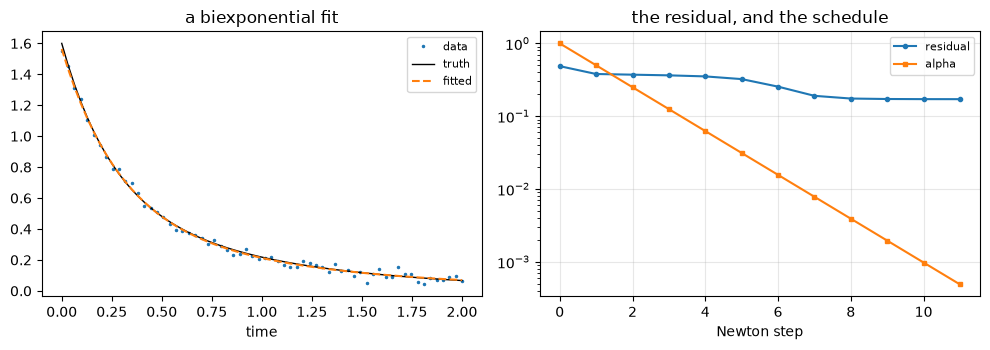

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(TIME, data, ".", markersize=3, label="data")
axes[0].plot(TIME, biexponential(TRUTH), "k-", linewidth=1, label="truth")
axes[0].plot(TIME, biexponential(found.solution), "--", label="fitted")
axes[0].set_xlabel("time")
axes[0].legend(fontsize=8)
axes[0].set_title("a biexponential fit")
axes[1].semilogy(found.residual_norms, "o-", markersize=3, label="residual")
axes[1].semilogy(found.alphas, "s-", markersize=3, label="alpha")
axes[1].set_xlabel("Newton step")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_title("the residual, and the schedule")
figure.tight_layout()

figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "irgnm.png", dpi=120)